# Machine Failure Prediction

Objective:
- To predict whether a machine is likely to fail based on operational conditions, usage patterns, and wear indicators, enabling proactive maintenance and risk mitigation.

Business Use Cases
- Predictive maintenance planning: Identify machines at high risk of failure and schedule maintenance before breakdown occurs.
- Operational risk control: Reduce unplanned downtime and safety incidents caused by unexpected equipment failure.
- Maintenance resource optimization: Prioritize maintenance activities based on predicted failure risk rather than fixed schedules.
- Reliability and asset performance optimization: Improve equipment lifespan and overall equipment effectiveness (OEE) through data-driven insights.
- Condition-based monitoring & alerts: Trigger alerts when operational conditions exceed safe thresholds associated with failures.

ML Framing:
- Type: Binary Supervised Classification
- Target: Machine Failure (Yes / No)

---

## Exploratory Data Analysis (EDA)

1. Data Overview
    - Data Summary
    - Descriptive Statistics

2. Data Quality
    - Missing Data Analysis
    - Duplicate rows

3. Numerical Variable Analysis
    - Distribution Analysis (Histograms)
    - Outlier Detection (Box Plots)
    - Feature-Target Relationships
    - Multicollinearity (Feature correlation, VIF)

4. Categorical Variable Analysis
    - Cardinality
    - Distribution Analysis (Barplot, Boxplot against Target)

#### 1. Data Overview
- Data Summary
- Descriptive Statistics

In [1]:
import warnings
warnings.filterwarnings('ignore')

from IPython.display import Image, display
import pandas as pd
from functions.eda_analysis import EDA_Analysis as EA
from functions.feature_eng import Feature_Engineering as FE
from functions.model import ModelTrainer as MT
from functions.eval import Model_Interpretability as MI
from functions.classification_pipeline import ClassificationPipeline as CP, ClassificationPipelineConfig as CPC
import joblib


In [2]:
df = pd.read_csv('../data/machine_failure.csv')

In [3]:
df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


Column renaming for ecosystem friendly

In [4]:
df.columns = df.columns.str.lower()

In [5]:
df.columns.tolist()

['udi',
 'product id',
 'type',
 'air temperature [k]',
 'process temperature [k]',
 'rotational speed [rpm]',
 'torque [nm]',
 'tool wear [min]',
 'machine failure',
 'twf',
 'hdf',
 'pwf',
 'osf',
 'rnf']

In [6]:
df.rename(columns={'product id': 'product_id',
                   'air temperature [k]': 'air_temp',
                   'process temperature [k]': 'process_temp',
                   'rotational speed [rpm]': 'rotational_speed',
                   'torque [nm]': 'torque',
                   'tool wear [min]': 'tool_wear',
                   'machine failure': 'machine_failure'}, inplace=True)

In [7]:
df.head()

,udi,product_id,type,air_temp,process_temp,rotational_speed,torque,tool_wear,machine_failure,twf,hdf,pwf,osf,rnf
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


Drop unnecessary column

In [8]:
df.drop(columns=['udi','product_id'], inplace=True)

In [9]:
df.head()

,type,air_temp,process_temp,rotational_speed,torque,tool_wear,machine_failure,twf,hdf,pwf,osf,rnf
0,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


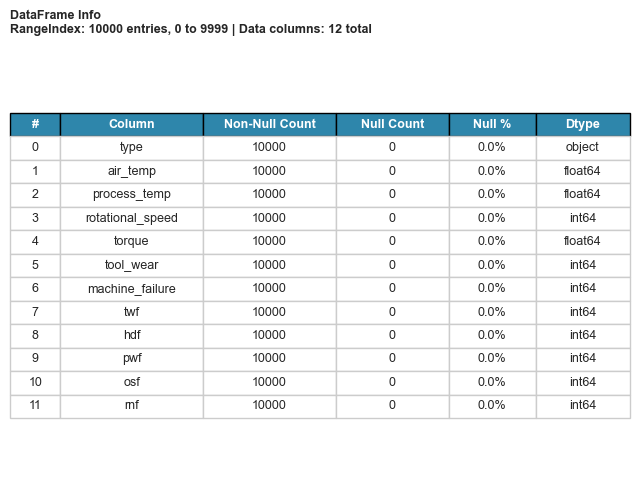

In [10]:
fig = EA.data_info(df)
fig.show()

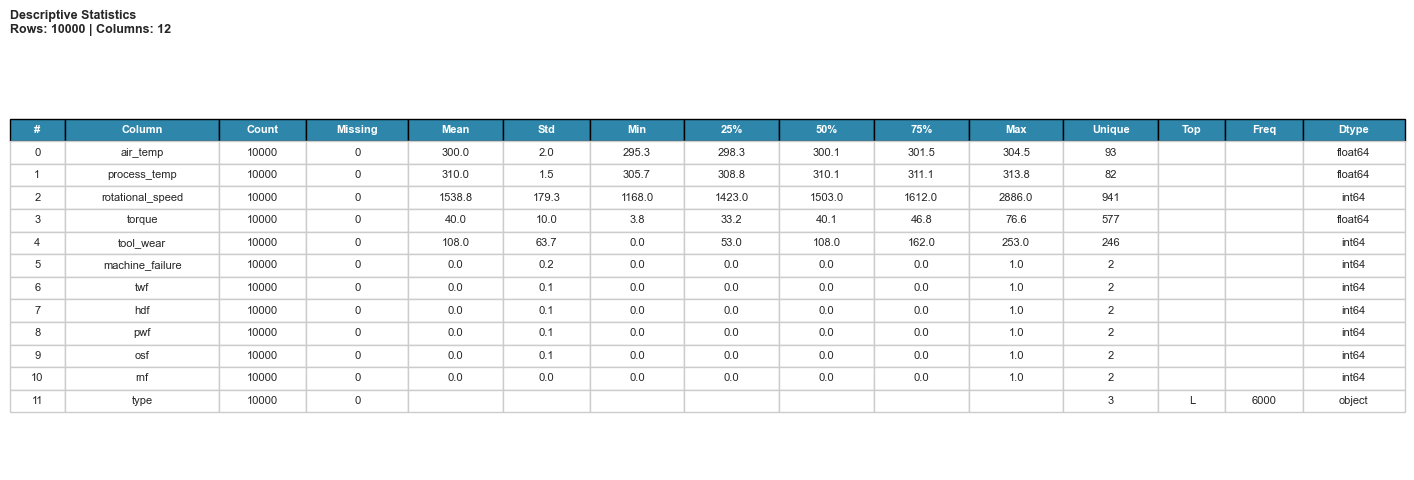

In [11]:
fig = EA.descriptive_stats(df)
fig.show()

There are 5 numerical, 5 binary, and 1 categorical features. With target variable (machine_failure) to be in binary type as well

#### 2. Data Quality
- Missing Data Analysis

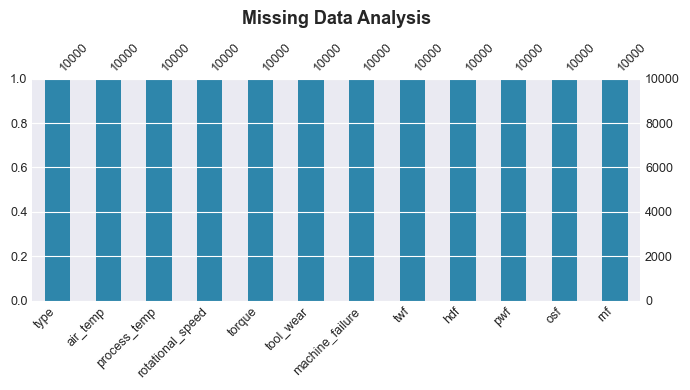

In [12]:
fig = EA.missing_plot(df)
fig.show()

This dataset does not contain any missing value

#### 3. Univariate Analysis
- Distribution Analysis (Histograms)
- Outlier Detection (Box Plots)

##### Distribution Analysis
Analyzing the distribution of numerical features to understand their spread, central tendency, and potential skewness.

In [13]:
df.columns.tolist()

['type',
 'air_temp',
 'process_temp',
 'rotational_speed',
 'torque',
 'tool_wear',
 'machine_failure',
 'twf',
 'hdf',
 'pwf',
 'osf',
 'rnf']

In [14]:
num_features = [ 'air_temp', 'process_temp', 'rotational_speed', 'torque', 'tool_wear']
binary_features = ['twf', 'hdf', 'pwf', 'osf', 'rnf']
cat_features = ['type']
target = ['machine_failure']

Binary Features Analysis

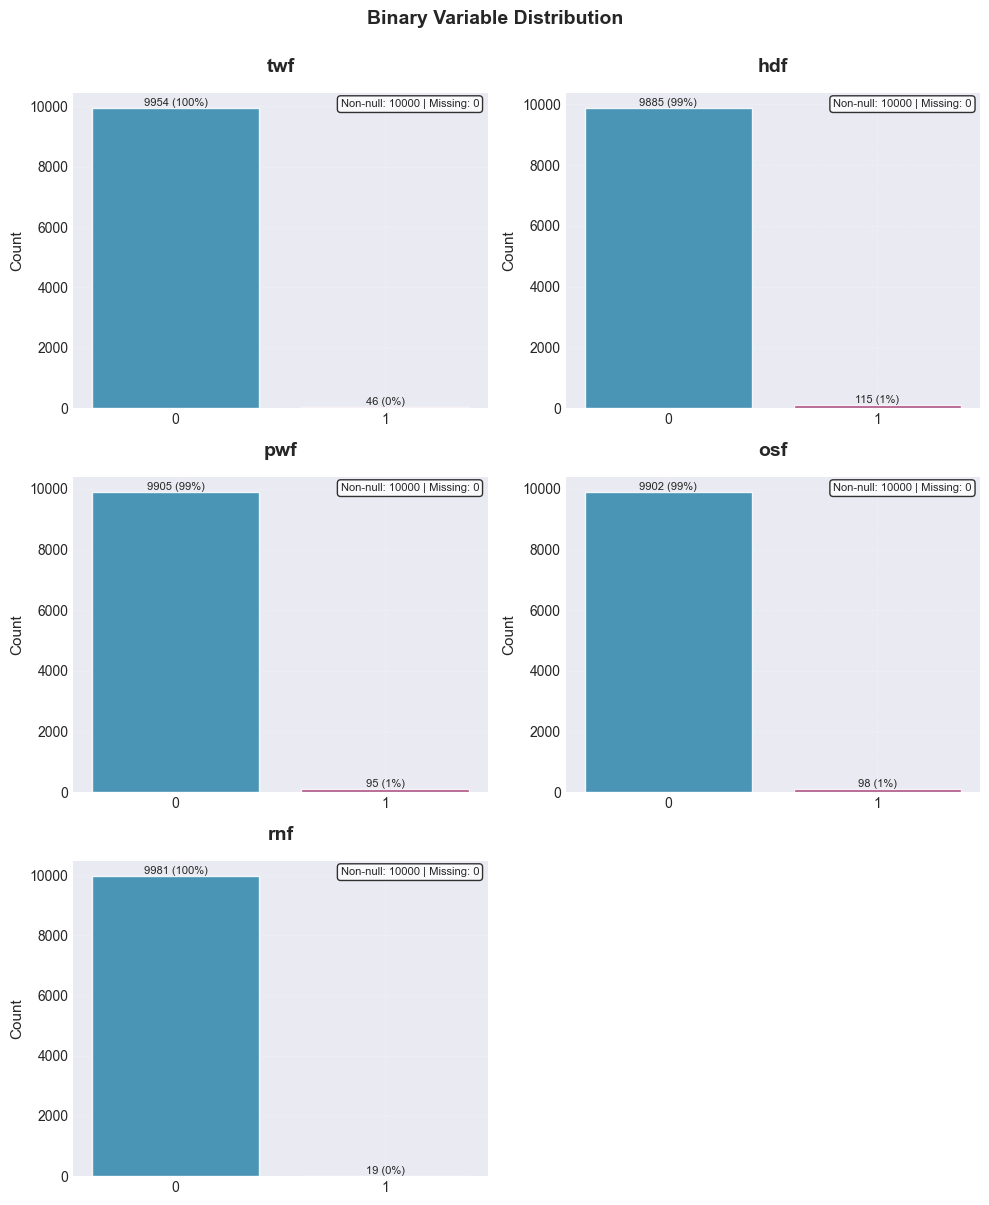

In [15]:
fig = EA.binary_bar_plot(df, variables=binary_features, combined=True)
fig

In [16]:
fig = EA.binary_crosstab_with_target(
        data=df,
        target='machine_failure',
        variables=binary_features,)
fig

machine_failure         0         1
feature value                      
twf     0        0.970565  0.029435
        1        0.000000  1.000000
hdf     0        0.977339  0.022661
        1        0.000000  1.000000
pwf     0        0.975366  0.024634
        1        0.000000  1.000000
osf     0        0.975661  0.024339
        1        0.000000  1.000000
rnf     0        0.966136  0.033864
        1        0.947368  0.052632

### Target Leakage Analysis

- All failure-mode binary features exhibit conditional dependence with the target variable (machine_failure). 
- Conditional probability analysis shows that when several of these features take the value 1, the target variable is always 1, indicating deterministic relationships.
- the features twf, hdf, pwf, and osf demonstrate perfect conditional failure with the target variable, where:

        P(machine_failure = 1 | feature = 1) = 1.0

- This confirms that these variables encode post-failure information rather than pre-failure predictive signals. As such, they constitute hard target leakage and must be excluded from model training.

- The feature rnf (random failure) shows a different conditional pattern, with a non-perfect but elevated failure probability when active. 
- However, rnf represents a failure classification label that is only available after a failure has occurred. 
- Despite not being deterministic, it still contains outcome-derived information and therefore represents soft target leakage.

- All failure-mode indicators (twf, hdf, pwf, osf, rnf) are excluded from the predictive feature set to ensure realistic model performance and prevent leakage-driven bias.

In [17]:
df = df.drop(columns=binary_features)

Numerical Features Analysis

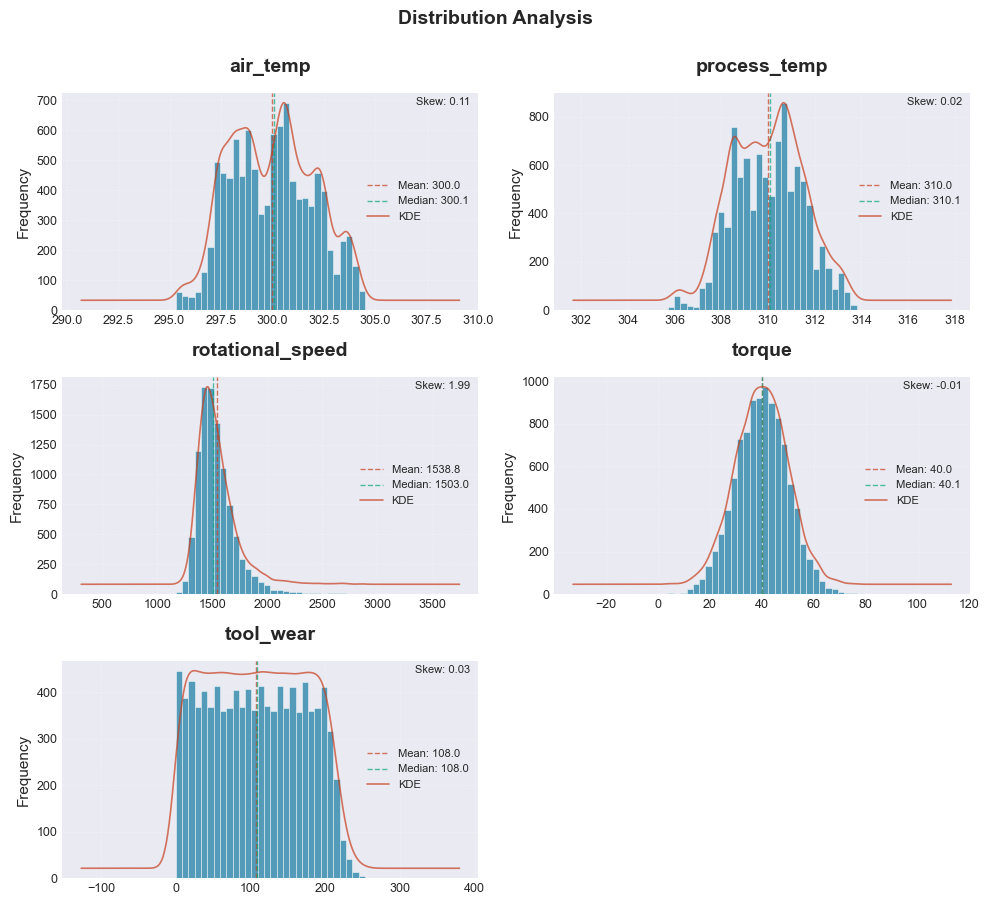

In [18]:
fig = EA.hist_plot(df, variables=num_features, combined=True)

1. air_temp:
- skew = 0.11
- mean ≈ median
- distribution shows it is near-symmetric and bell shaped.
- no transformation needed

2. process_temp:
- skew = 0.02
- mean ≈ median
- distribution shows clean and symmetric distribution
- no transformation needed

3. torque:
- skew = -0.01
- mean ≈ median
- distribution shows almost perfect symmetric distribution
- no transformation needed

4. tool_wear:
- skew = 0.03
- mean ≈ median
- distribution shows roughly uniform or mildly flat
- no long tail means it is not skewed
- no transformation needed

5. rotational_speed:
- skew = 1.99, means it is highly skewed
- long right tail
- mean > median
- need transformation, could use log transformation

Outlier Detection

Box plots to identify outliers and understand the spread of data.

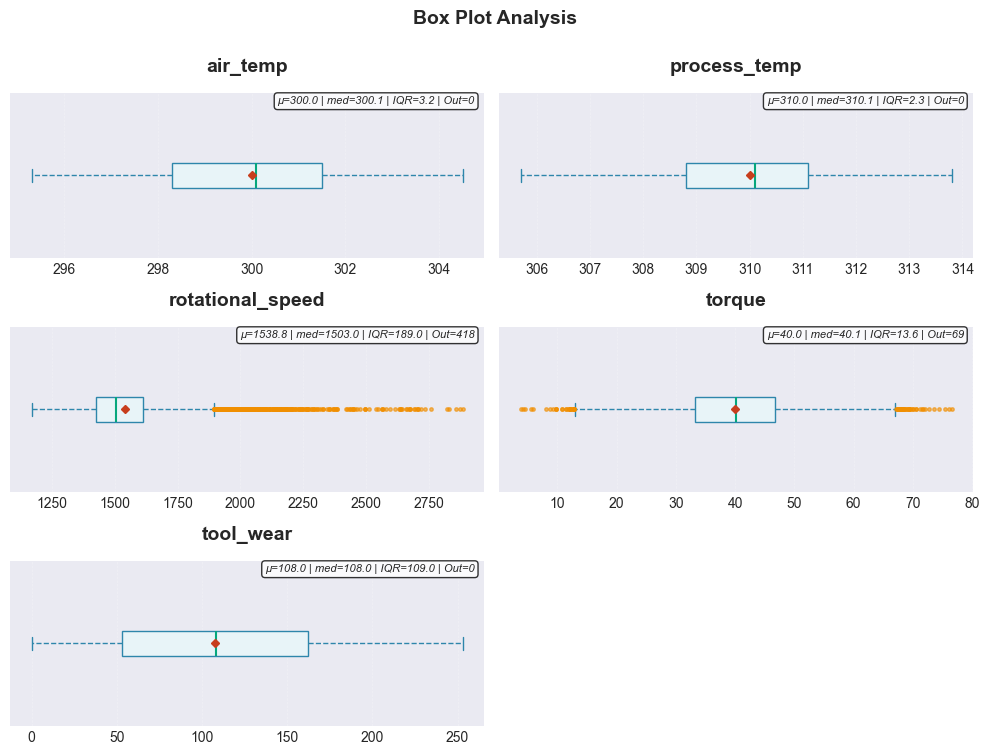

In [19]:
fig = EA.box_plot(df, variables=num_features, combined=True)
fig

1. air_temp, process_temp, and tool_wear:
- mean ≈ median
- tight IQR (range value of the box, of the whiskers)
- 0 outliers
- clean, stable distribution
- no transformation and no capping needed

2. torque:
- mean ≈ median
- moderate IQR
- has 69 outliers
- however, torque spikes can be mechanically meaningful, which could be correlated to failure risk
- these are signal not noise data.
- thus, keep it as it is, no need for capping or transformation

3. rotational_speed:
- mean > median
- large IQR
- 418 outliers with long right tail
- since these are real operation conditions and not noise, keep the outliers

Categorical feature analysis

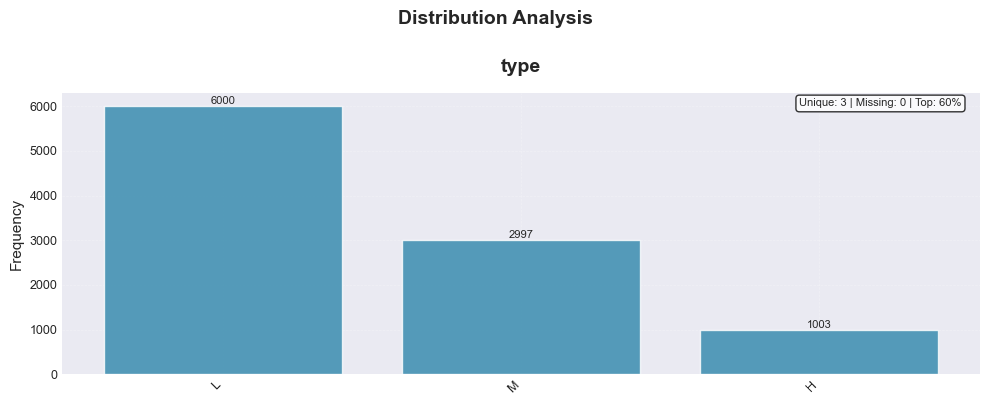

In [20]:
fig = EA.categorical_bar_plot(df, variables=cat_features, combined=True)
fig

Feature: type
- 3 categories: L, M, H
- No missing value
- Distribution:
    - L: 6000 (60%)
    - M: 2997 (30%)
    - H: 1003 (10%)

- This dataset is dominated by low-type (L) machines, with progressively fewer medium (M) and high (H) types.
- The imbalance in values is acceptable since this is a feature variable
- Proceed to one-hot encoded this feature.

Check if machine type heavily affect machine_failure

In [21]:
df.groupby('type')['machine_failure'].mean().mul(100).round(2)

type
H    2.09
L    3.92
M    2.77
Name: machine_failure, dtype: float64

- Failure contribution:
    - Type H: 2.09%
    - Type L: 3.92%
    - Type M: 2.77% 

- There are some differences in failure rate contribution based on machine type, however it is not extreme
- Means the machine type won't dominate the model alone
- It also means this feature would not contribute to data leakage and overfitting risk

Target Variable Analysis

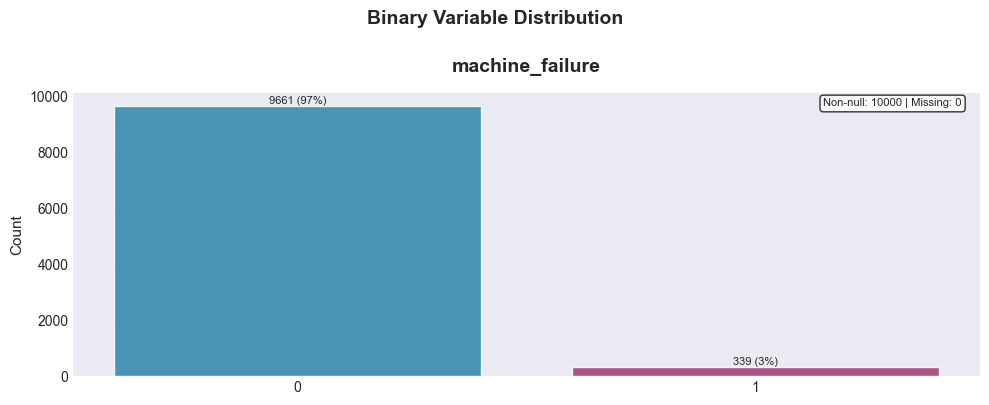

In [22]:
fig = EA.binary_bar_plot(df, variables=target, combined=True) 
fig

Target: machine_failure
- 0 (No failure): 9,661 samples, approximately 97%
- 1 (Failure): 339 samples, approximately 3%
- Machine failure is a rare event, affectiing only around 3% of observations
- It is a highly imbalanced classification problem
- Strategy:
    1. Use stratified train-test split
        - Use stratified sampling to preserve the original class distribution of the target variable in both training and test sets
    2. Evaluation metrics: 
        - Given the strong class imbalance, model performance will be evaluated using:
            1. Recall (positive class) to minimize missed failure events
            2. F1-score to balance recall and precision
            3. ROC-AUC to assess overall discriminative ability 
    3. For baseline linear model such as logistic regression, apply class_weight='balanced'
    4. Explore resampling technique such as SMOTE to the training set.

Correlation Analysis

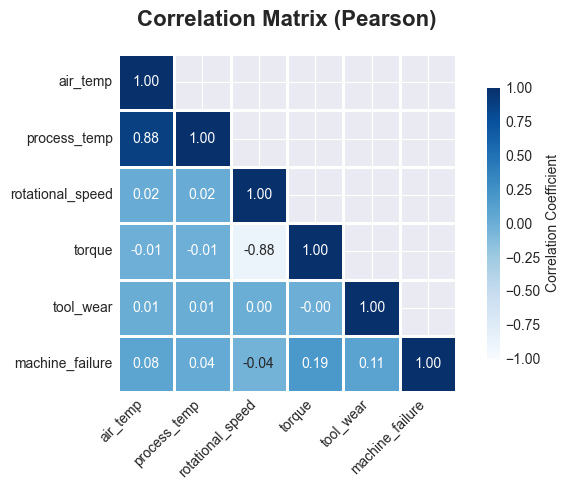

In [23]:
fig = EA.corr_matrix(df, variables=num_features + binary_features + target, method='pearson')
fig

- Strong positive correlation between process_temp and air_temp. Potential multicollinearity
- Strong negative correlation between torque and rotational_speed. Potential multicollinearity
- No single feature has high linear correlation to machine_failure

Dependency matrix

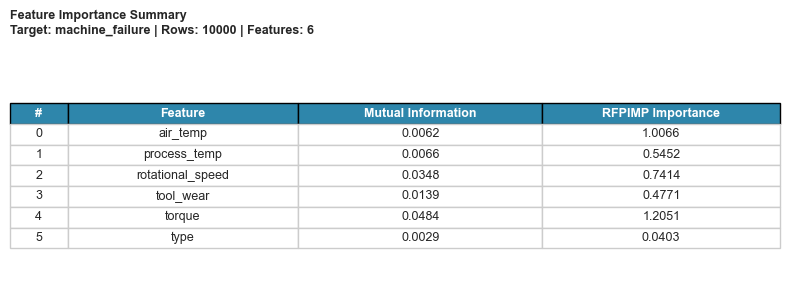

In [24]:
importance_df = EA.importance_with_target(data=df, target='machine_failure')

1. torque: highest Mutual Information (MI) and RF Importance
    - Strongest predictor of machine_failure
    - Likely reflects mechanical stress
    - Correlated non-linearly to machine_failure
    - Core feature and must keep

2. rotational_speed
    - Strong signal, complementary to torque

3. tool_wear
    - Important contextual feature
4. air_temp and process_temp: low MI and moderate RF
    - Provide environmental context
    - Might not expecting dominance in machine_failure
5. type: lowest MI and RF
    - Captures background reliability differences
    - Minimal standalone importance
    - Possible low impact in model

These results confirm that machine_failure is driven by nonlinear interactions rather than linear effects

---
## Feature Engineering

1. Apply log feature transformations if |skewness|>=1.5, then plot the distribution and box plot again
2. Create new meaningful features with aim to improve failure discrimination in linear and nonlinear models
3. Plot correlation matrix and dependency importance again
4. Encode categorical variables (one-hot encoding)

1. Apply log feature transformation

In [25]:
df

,type,air_temp,process_temp,rotational_speed,torque,tool_wear,machine_failure
0,M,298.1,308.6,1551,42.8,0,0
1,L,298.2,308.7,1408,46.3,3,0
2,L,298.1,308.5,1498,49.4,5,0
3,L,298.2,308.6,1433,39.5,7,0
4,L,298.2,308.7,1408,40.0,9,0
...,...,...,...,...,...,...,...
9995,M,298.8,308.4,1604,29.5,14,0
9996,H,298.9,308.4,1632,31.8,17,0
9997,M,299.0,308.6,1645,33.4,22,0
9998,H,299.0,308.7,1408,48.5,25,0


In [26]:
df_t = FE.log_transform_skewed_features(df=df, columns='rotational_speed', skew_threshold=1)

In [27]:
df_t[num_features].skew()

air_temp            0.114274
process_temp        0.015027
rotational_speed    1.309708
torque             -0.009517
tool_wear           0.027292
dtype: float64

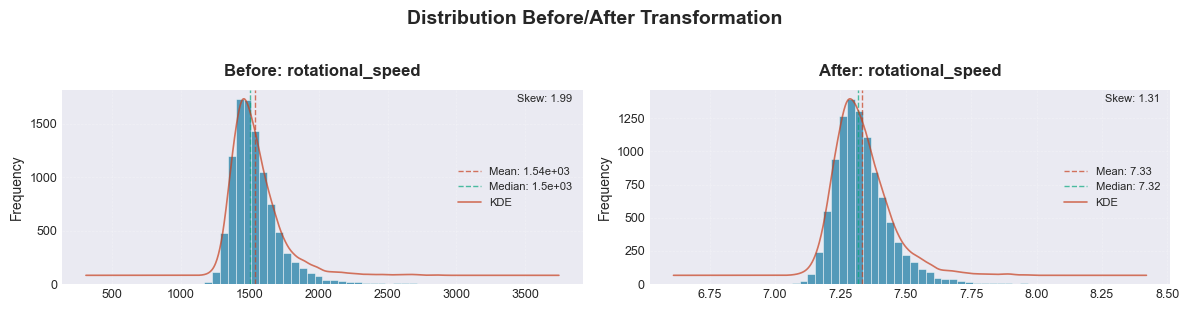

In [28]:
fig = FE.plot_distribution_before_after_log_transform(before_df= df,
                                                      after_df= df_t, 
                                                      columns='rotational_speed',
                                                      combined=True
                                                      )

rotational_speed:
- skewness reduced from 1.99 to 1.31 after taking log transform
- this is a meaningful improvement, even though skew is not near zero
- as a rule of thumb, a skew of 1.0 - 1.5 is acceptable, especially for real-world mechanical data

New feature generation

In [29]:
df_t['mechanical_power'] = df_t['torque'] * df_t['rotational_speed']

- capture stress regime
- nonlinear interaction

In [30]:
df_t['wear_stress'] = df_t['torque'] * df_t['tool_wear']


- old tool + high torque could be failure-prone
- strongly aligened with degradation theory

In [31]:
df_t['temp_delta'] = df_t['process_temp'] - df_t['air_temp']

- capture internal heating

In [32]:
num_features.extend(['mechanical_power','wear_stress', 'temp_delta'])

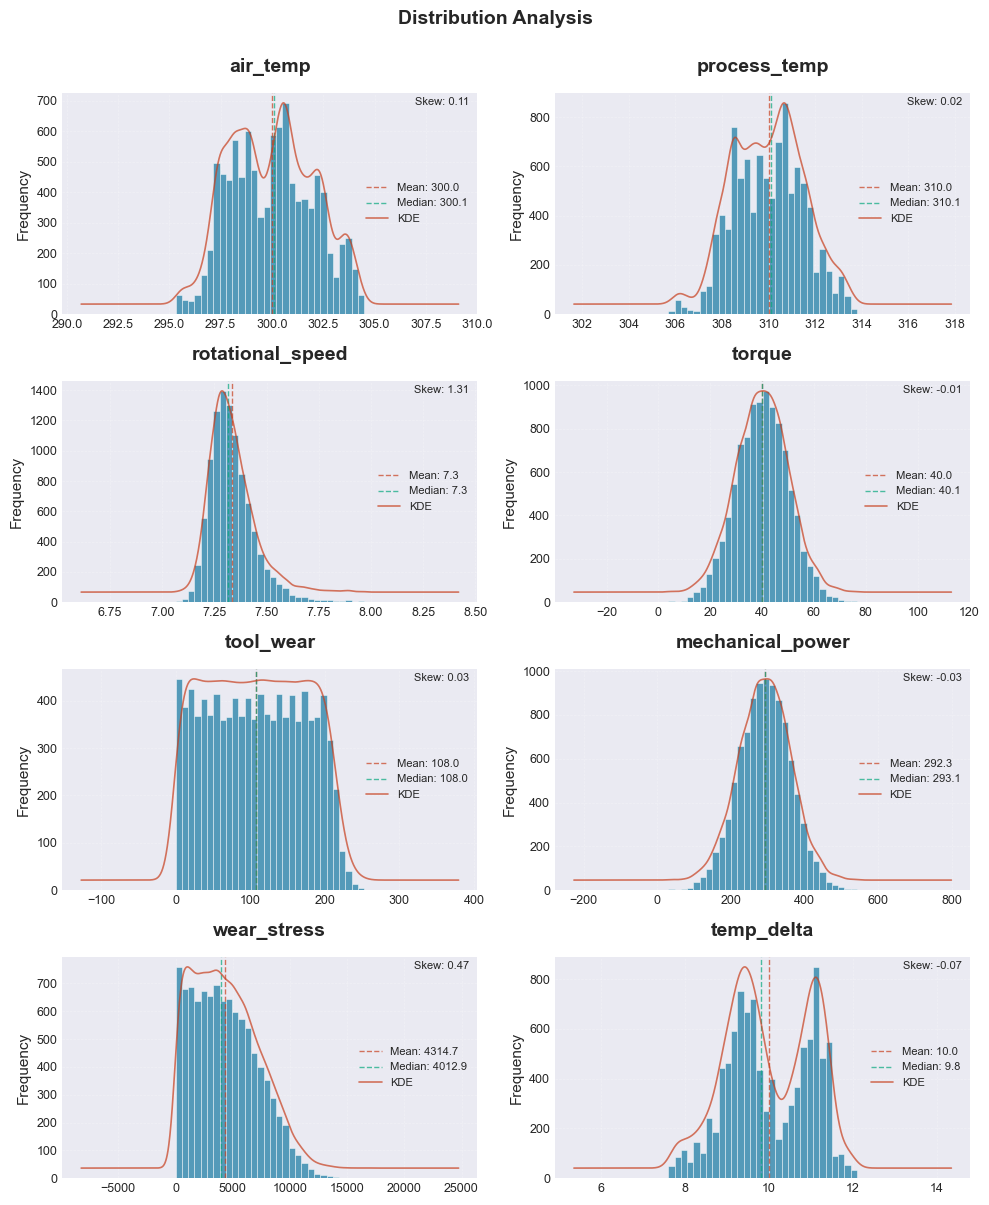

In [33]:
fig = EA.hist_plot(df_t, variables=num_features, combined=True)

- Engineered interactions such as mechanical_power, wear_stress, and temp_delta exhibit well-behaved distributions without extreme skewness.
- No additional transformations should be applied to these features.

Encode categorical variable

- One-hot encoding method is selected since there's no clear order pattern to use ordinal encoding

In [34]:
df_t

,type,air_temp,process_temp,rotational_speed,torque,tool_wear,machine_failure,mechanical_power,wear_stress,temp_delta
0,M,298.1,308.6,7.347300,42.8,0,0,314.464427,0.0,10.5
1,L,298.2,308.7,7.250636,46.3,3,0,335.704424,138.9,10.5
2,L,298.1,308.5,7.312553,49.4,5,0,361.240143,247.0,10.4
3,L,298.2,308.6,7.268223,39.5,7,0,287.094809,276.5,10.4
4,L,298.2,308.7,7.250636,40.0,9,0,290.025420,360.0,10.5
...,...,...,...,...,...,...,...,...,...,...
9995,M,298.8,308.4,7.380879,29.5,14,0,217.735932,413.0,9.6
9996,H,298.9,308.4,7.398174,31.8,17,0,235.261936,540.6,9.5
9997,M,299.0,308.6,7.406103,33.4,22,0,247.363853,734.8,9.6
9998,H,299.0,308.7,7.250636,48.5,25,0,351.655822,1212.5,9.7


In [35]:
df_enc = FE.encode_categorical_features(df_t, columns=["type"], encoding="onehot")
df_enc.head()

,air_temp,process_temp,rotational_speed,torque,tool_wear,machine_failure,mechanical_power,wear_stress,temp_delta,type_H,type_L,type_M
0,298.1,308.6,7.347300,42.8,0,0,314.464427,0.0,10.5,0,0,1
1,298.2,308.7,7.250636,46.3,3,0,335.704424,138.9,10.5,0,1,0
2,298.1,308.5,7.312553,49.4,5,0,361.240143,247.0,10.4,0,1,0
3,298.2,308.6,7.268223,39.5,7,0,287.094809,276.5,10.4,0,1,0
4,298.2,308.7,7.250636,40.0,9,0,290.025420,360.0,10.5,0,1,0


---

## Model Training

### Train-Test Split

- Split train and test data
- Scale train and transform both train and test

In [36]:
X = df_enc.drop(columns=['machine_failure'])
y = df_enc['machine_failure']

In [37]:
X_train, X_test, y_train, y_test = MT.split_train_test(X, y, test_size=0.2, stratify=True, random_state=42)

- set stratify = True to preserve the original class distribution of the target variable in both training and test sets

In [38]:
X_train.describe()

,air_temp,process_temp,rotational_speed,torque,tool_wear,mechanical_power,wear_stress,temp_delta,type_H,type_L,type_M
count,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000
mean,300.005450,310.006062,7.333609,40.003363,107.685000,292.392430,4302.684150,10.000613,0.098625,0.603750,0.297625
std,1.996844,1.479432,0.108267,10.019546,63.612002,70.044799,2820.177264,0.999854,0.298176,0.489148,0.457242
min,295.300000,305.700000,7.063904,3.800000,0.000000,30.278298,0.000000,7.600000,0.000000,0.000000,0.000000
25%,298.300000,308.800000,7.260523,33.200000,53.000000,244.981742,1953.325000,9.300000,0.000000,0.000000,0.000000
50%,300.100000,310.100000,7.315884,40.100000,107.000000,293.211706,3998.700000,9.800000,0.000000,1.000000,0.000000
75%,301.500000,311.100000,7.386471,46.800000,163.000000,340.630884,6265.050000,11.000000,0.000000,1.000000,1.000000
max,304.500000,313.800000,7.967973,76.600000,253.000000,543.163692,16497.000000,12.100000,1.000000,1.000000,1.000000


In [39]:
X_train_s, X_test_s = MT.scale_after_split(X_train, X_test, scaler="standard")

In [40]:
X_train_s.describe()

,air_temp,process_temp,rotational_speed,torque,tool_wear,mechanical_power,wear_stress,temp_delta,type_H,type_L,type_M
count,8.000000e+03,8.000000e+03,8.000000e+03,8.000000e+03,8.000000e+03,8.000000e+03,8.000000e+03,8.000000e+03,8.000000e+03,8.000000e+03,8.000000e+03
mean,1.758593e-15,1.053468e-14,5.364598e-16,-1.474376e-16,-3.064216e-17,8.055778e-16,-1.887379e-17,-3.383960e-16,-1.776357e-17,-3.819167e-17,1.154632e-17
std,1.000063e+00,1.000063e+00,1.000063e+00,1.000063e+00,1.000063e+00,1.000063e+00,1.000063e+00,1.000063e+00,1.000063e+00,1.000063e+00,1.000063e+00
min,-2.356591e+00,-2.910801e+00,-2.491266e+00,-3.613500e+00,-1.692947e+00,-3.742327e+00,-1.525774e+00,-2.401113e+00,-3.307812e-01,-1.234366e+00,-6.509538e-01
25%,-8.541261e-01,-8.152711e-01,-6.750978e-01,-6.790515e-01,-8.597185e-01,-6.769047e-01,-8.331058e-01,-7.007585e-01,-3.307812e-01,-1.234366e+00,-6.509538e-01
50%,4.735268e-02,6.349964e-02,-1.637286e-01,9.645501e-03,-1.076908e-02,1.169719e-02,-1.077958e-01,-2.006543e-01,-3.307812e-01,8.101325e-01,-6.509538e-01
75%,7.485028e-01,7.394771e-01,4.882874e-01,6.783803e-01,8.696230e-01,6.887231e-01,6.958742e-01,9.995958e-01,-3.307812e-01,8.101325e-01,1.536207e+00
max,2.250967e+00,2.564616e+00,5.859630e+00,3.652753e+00,2.284539e+00,3.580379e+00,4.324224e+00,2.099825e+00,3.023147e+00,8.101325e-01,1.536207e+00


### Model Selection & Training

**Models to evaluate:**
1. Logistic Regression
    - Serves as a baseline model
    - Provides a reference point to assess gains from nonlinear models
    - Applies class weight to address class imbalance
2. Random Forest Classifier
    - Captures nonlinear relationships and feature interactions
    - Robust to multicollinearity and feature scaling
    - Well-suited for tabular data and interaction-heavy problems
3. XGBoost Classifier
    - Gradient-boosted tree model optimized for tabular data
    - Efficiently models nonlinear interactions
    - Supports class imbalance handling via scale_pos_weight

**Approach:**
1. Stratified Cross-Validation
    - Used to preserve the minority class distribution across folds
    - Ensures stable and reliable performance estimates for rare-event prediction
2. Evaluation Metrics
    - Due to the imbalanced target variable, model performance is evaluated using:
        1. Recall(positive class) - primary metric to minimize missed failure events
        2. F1-score - balances recall and precision
        3. ROC-AU - measures overall discriminative ability
        4. Confusion matrix - provides interpretable error analysis
3. Class Imbalance Handling
    - Logistic Regression uses class_weight='balanced'
    - Tree-based models (Random Forest and XGBoost) rely on class weighting or scale_pos_weight rather than resampling by default
4. Hyperparameter Tuning
    - Hyperparameters are tuned using GridSearchCV, with StratifiedKFold implemented
    - Model selection prioritizes on recall-focused metrics rather than accuracy

**Model Selection:**
The final model is selected based on:
1. Ability to detect failure events (high recall)
2. Generalization performance on the test set

Train 3 models with GridSearchCV:
- logreg, random_forest, xgboost

In [41]:
models = MT.train_classification(
    X_train_s,
    y_train,
    cv=5,
    scoring="recall",        # primary metric for imbalanced target
    stratified_cv=True,      # uses StratifiedKFold when True
    random_state=42,
    n_jobs=-1,
    verbose=0,
    refit=True,              # refit best model on full training set
)

Pick the best by CV score
- Best mean recall 

In [42]:
best_model = MT.select_best(models)
best_model.name, best_model.best_score, best_model.best_params

('random_forest',
 0.8818181818181818,
 {'class_weight': 'balanced',
  'max_depth': 5,
  'max_features': None,
  'min_samples_leaf': 4,
  'min_samples_split': 2,
  'n_estimators': 200})

In [43]:
# Evaluate ALL models

metrics = MT.evaluate_classification_all(
    results=models,
    X_train=X_train_s, y_train=y_train,
    X_test=X_test_s, y_test=y_test,
    metrics=["recall", "f1", "roc_auc"],
    fit_metric="recall",
    overfit_gap=0.10,
    overfit_train_min=0.85,
    underfit_max=0.60,
    decimals=3,
 )
metrics

,model,fit_status,train_recall,test_recall,train_f1,test_f1,train_roc_auc,test_roc_auc,gap_recall
0,random_forest,ideal,0.967,0.912,0.605,0.564,0.993,0.983,0.055
1,logistic_regression,ideal,0.852,0.882,0.272,0.288,0.923,0.933,-0.030
2,xgboost,ideal,0.904,0.853,0.802,0.779,0.992,0.977,0.051


Explanation:

1. Random Forest model
    - The best overall for failure detection
    - Highest recall at 0.912, which means it predicts the most failures correctly
    - Very strong ROC-AUC at 0.983
    - Small recall gap at 0.055, means this model is not overfit
    - However, F1 is moderate, which is expected when recall is prioritized
    - Conclusion: Random Forest model is the best model when missing failures is costly

2. Logistic Regression
    - A stable model, but still weak compared to others
    - Lowest train recall at 0.852
    - Negative recall gap, could prone to slightly underfitting
    - It is a good baseline model, but it is insufficient for this rare-event, nonlinear problem

3. XGBoost
    - Has lower recall than Random Forest
    - However, it has the best F1-score at 0.779, which mean this model is also precise
    - Strong ROC-AUC as well at 0.977, but lower than Random Forest
    - Also has small generalization gap at 0.051
    - Second best model after Random Forest

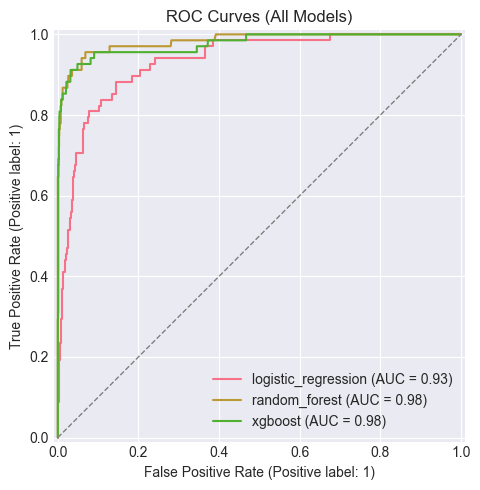

In [44]:
fig = MT.plot_roc_curves(
    models,                 # dict returned by MT.train_classification
    X_test_s,
    y_test,
    title="ROC Curves (All Models)"
)
fig.show()

Interpretation:

- All models discriminate failures from non-failures well
- Both tree-based models Random Forest and XGBoost are significantly stronger than the linear baseline model
- Random Forest and XGBoost are nearly identical in ranking ability
- Proceed with Random Forest, despite almost similar ROC-AUC with XGBoost, Random Forest delivers higher recall which better aligns with the cost of missed failures

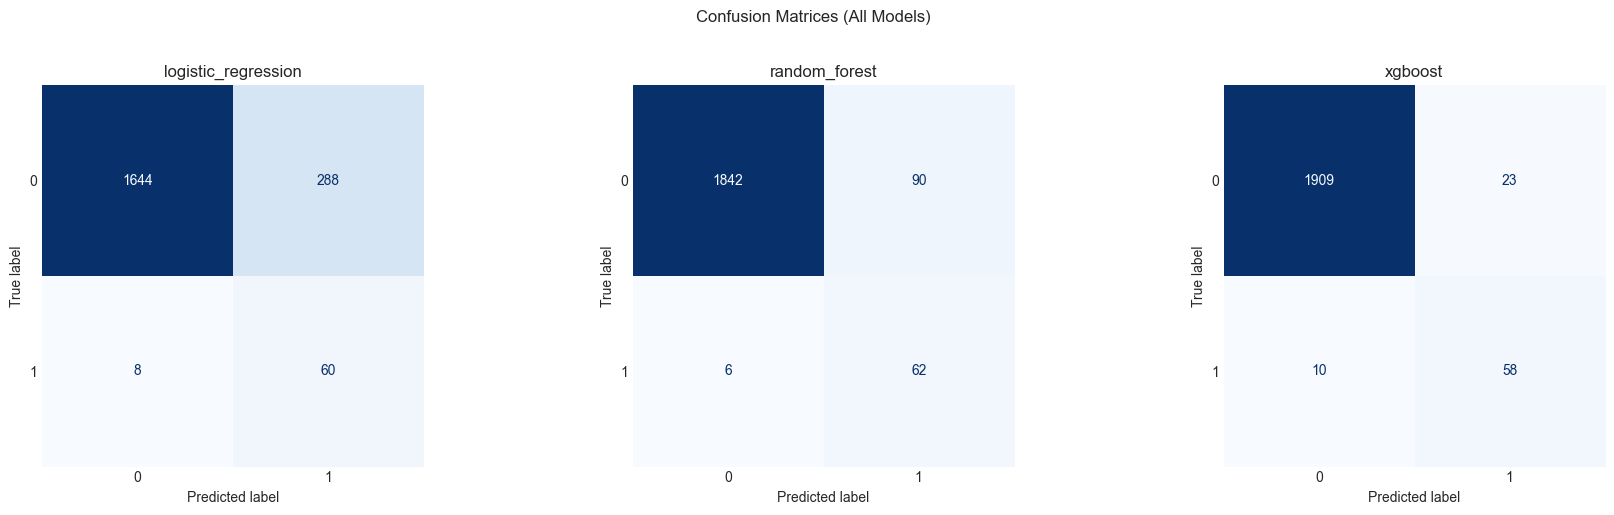

In [45]:
fig = MT.plot_confusion_matrices(
    models,
    X_test_s,
    y_test,
    normalize=None,
    title="Confusion Matrices (All Models)"
)
fig.show()

Positive class = machine failure (1)

- False Negatives (FN): missed failures (very costly)
- True Positives (TP): correctly detected failures
- False Positive (FP): unnecessary maintenance checks (manageable cost)

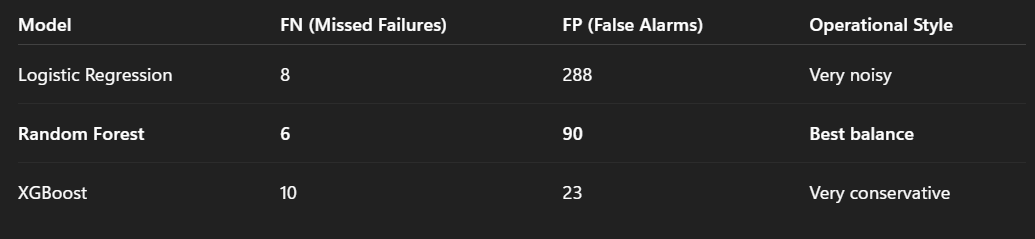

In [46]:
display(Image(filename='../data/classification_confusionmatrix_table.png', width=800))

- Choose Random Forest since it has the lowest missed failure and best balance between both False Negative and False Positive
- Second option would be XGBoost if the business wants to reduce False Positive further and can tolerate more missed failures

---

## Model Interpretability

### Feature Importance
Understanding which features contribute most to predictions.

### SHAP Analysis
SHAP (SHapley Additive exPlanations) values for detailed model interpretation:

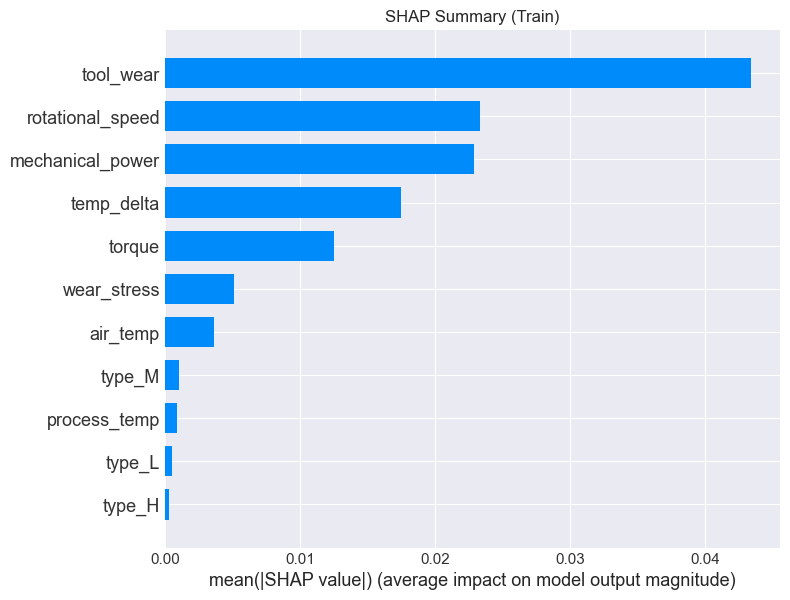

In [47]:
fig = MI.shap_summary_plot(
    model=best_model,
    X=X_train_s,                 
    plot_type="bar",
    title="SHAP Summary (Train)"       
)

SHAP Summary:

1. tool_wear
    - The strongest driver, with largest average SHAP impact
    - It indicates accumulated degradation is the biggest risk factor
    - Meaning, machines fail due to how worn they are, not just momentary stress

2. torque
    - Second strongest contributor
    - Represents instantaneous mechanical load
    - High torque significantly increases failure risk

3. rotational_speed
    - Strong standalone contributor
    - Confirms speed matter independently of torque
    - Certain speed ranges are significantly riskier, even before interaction effects

4. temp_delta
    - Stronger than raw temperatures (air_temp and process_temp)
    - Confirms the feature engineering creates a more informative feature than absolute temperature

5. Very low importance: type, process_temp, air_temp
    - Matches the MI results and correlation analysis
    - These are contextual features, not primary drivers

SHAP confirms that the model is learning from: Wear, mechanical stress, speed, and thermal stress



---

## Model Pipeline

In [48]:
cfg = CPC(
    target="machine_failure",
    auto_rename_columns=True,
    add_engineered_features=True,   # << adds mechanical_power, wear_stress, temp_delta
    log_rotational_speed=True,  
    categorical_features=["type"],
    encoding="onehot",
    scaler="standard",
    test_size=0.2,
    stratify=True,
    cv=5,
    scoring="recall",
    stratified_cv=True,
    refit=True,
    metric_set="imbalanced",
    metrics=["recall", "f1", "roc_auc"],
    pipeline_model_types=("logistic", "random_forest", "xgboost"),
    random_state=42,
    return_best_pipeline=True
)

models_pipe = CP.run(df, config=cfg)

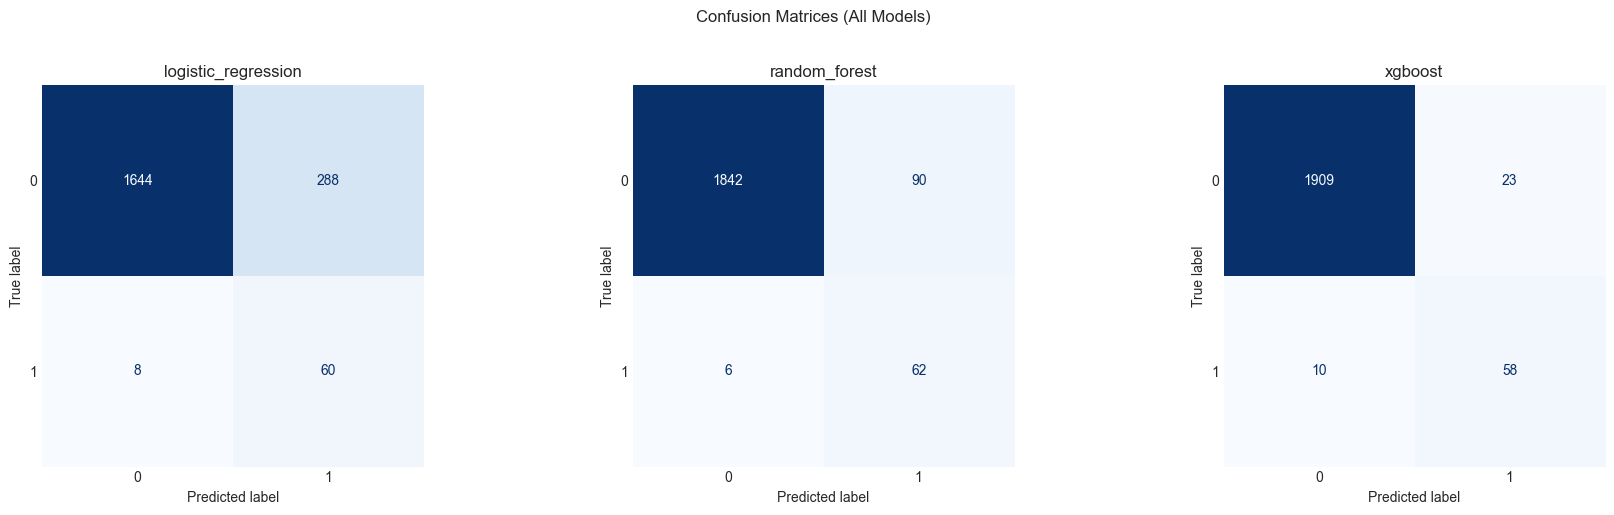

In [49]:
models_pipe.confusion_matrices_all

In [50]:
models_pipe.metrics_table

,model,fit_status,train_recall,test_recall,train_f1,test_f1,train_roc_auc,test_roc_auc,gap_recall
0,random_forest,ideal,0.967,0.912,0.605,0.564,0.993,0.983,0.055
1,logistic_regression,ideal,0.852,0.882,0.272,0.288,0.923,0.933,-0.030
2,xgboost,ideal,0.904,0.853,0.802,0.779,0.992,0.977,0.051


In [51]:
print(models_pipe.best_model.name)
print(models_pipe.best_model.best_params)

random_forest
{'class_weight': 'balanced', 'max_depth': 5, 'max_features': None, 'min_samples_leaf': 4, 'min_samples_split': 2, 'n_estimators': 200}


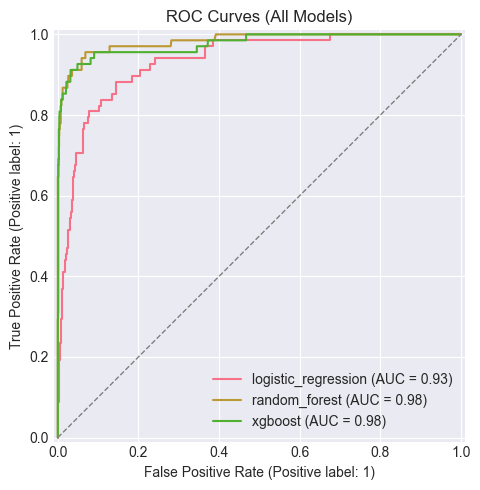

In [52]:
models_pipe.roc_curves_all

In [53]:
models_pipe.X_train

,air_temp,process_temp,rotational_speed,torque,tool_wear,mechanical_power,wear_stress,temp_delta,type_H,type_L,type_M
4058,302.0,310.9,7.284135,47.2,54,343.811163,2548.8,8.9,0,0,1
1221,297.0,308.3,7.244228,46.4,132,336.132157,6124.8,11.3,0,0,1
6895,301.0,311.6,7.213768,45.6,137,328.947835,6247.2,10.6,0,0,1
9863,298.9,309.8,7.252762,56.3,84,408.330524,4729.2,10.9,0,1,0
8711,297.1,308.5,7.458186,28.7,50,214.049943,1435.0,11.4,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...
980,296.1,306.7,7.251345,42.8,134,310.357565,5735.2,10.6,0,1,0
4266,302.7,311.1,7.273093,39.5,146,287.287158,5767.0,8.4,0,1,0
7772,300.3,311.5,7.289611,41.0,29,298.874031,1189.0,11.2,1,0,0
5780,301.7,311.2,7.325149,42.4,113,310.586316,4791.2,9.5,0,1,0


In [54]:
best_model_pipe = models_pipe.best_pipeline

In [55]:
best_model_pipe = models_pipe.best_pipeline
model_path = r"c:\Users\ashle\Project\usecase\models\best_classification_pipe.joblib"
joblib.dump(best_model_pipe, model_path)
print('Saved:', model_path)

Saved: c:\Users\ashle\Project\usecase\models\best_classification_pipe.joblib


In [56]:
models_pipe.best_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('feature_engineer', ...), ('preprocess', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,auto_rename_columns,True
,add_engineered_features,True
,log_rotational_speed,True
,extra_drop_columns,None
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have iden

In [57]:
model_path_load = r"c:\Users\ashle\Project\usecase\models\best_classification_pipe.joblib"
pipe_loaded = joblib.load(model_path_load)

In [58]:
new_data = pd.DataFrame([
    {
        'Type': 'M',
        'Air temperature [K]': 300.0,
        'Process temperature [K]': 310.0,
        'Rotational speed [rpm]': 1500.0,
        'Torque [Nm]': 400.0,
        'Tool wear [min]': 10.0,
    }
])

In [60]:
pred_class = pipe_loaded.predict(new_data)
pred_prob = pipe_loaded.predict_proba(new_data)

print('Predicted class:', pred_class)
print('Predicted failure probability:', pred_prob)

Predicted class: [1]
Predicted failure probability: [[0.08023472 0.91976528]]
